In [1]:
import pandas as pd
import numpy as np
import boto3
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn import clone

In [2]:
base_path = os.path.join(os.path.dirname(os.path.abspath('')), "data\\car_prices.csv")
df = pd.read_csv(base_path)

##### MAPE and MAE error analysis and final model export to .joblib format

*I decided to change approach to predicting. On the start I created feature based on the third quarter price to divide brands (normal/luxury). To be the problem more realistic I abandon the first idei and choose to predict the real price of choosed car. Firstly work was focused on cleaning data (unify names, deleting outliers such as like 1$ selling price). And I could end this in this momement but I wanted to divide model into two. Because the expensive brands had to low prices. And that was final approach of building model. To secure a final margin in price negotiations, I added a 15% markup to the expensive car models.*

In [ ]:
# PREPARING DATA SET
# cleaning states, bodies and models names
df['len_state'] = df['state'].apply(lambda x: len(x))
df = df[df['len_state'] <= 2]
df['body_clean'] = df['body'].astype(str).str.title().str.strip()
df['model_clean'] = df['model'].astype(str).str.title().str.strip()

# remove price NA, 1 and records without brands
df = df[(~df['sellingprice'].isna()) & (df['make']!='Unknown') & (df['sellingprice'] > 1)]

# CHOOSING LUXURY BRANDS
luxury_brands = ['Rolls-Royce','Ferrari','Lamborghini','Airstream','Tesla','Bentley','Aston Martin','Maserati', 'Porsche', 'Land Rover']
# 'Rolls-Royce','Ferrari','Lamborghini','Airstream','Tesla','Bentley','Aston Martin','Fisker','Maserati','Lotus','Porsche','Land Rover','Ram','Mercedes-Benz','Infiniti','Lexus','Bmw','Audi','Lincoln','Gmc','Subaru','Jaguar','Acura','Jeep','Cadillac','Hummer','Ford','Mini','Toyota','Kia','Nissan','Hyundai','Honda','Buick','Dodge','Chevrolet','Chrysler','Fiat'

# Features
df['is_luxury'] = df['make'].isin(luxury_brands).astype(int)
df['year_condition'] = df['year'] * df['condition']
df['car_age'] = 2026 - df['year']

*Applied Logarithmic Transformation to the target variable ('sellingprice') to handle right-skewness and minimize relative error (MAPE) across different price ranges.*

In [7]:
# PROFESSIONAL REGRESSION PIPELINE WITH LOG TRANSFORMATION
pipeline = Pipeline(steps=[
    ('encoder', TargetEncoder(cols=['make', 'model_clean', 'body_clean', 'state'])),
    ('regressor', XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ))
])

log_model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

model_luxury = clone(log_model)
model_normal = clone(log_model)

features = ['make', 'car_age', 'condition', 'odometer', 'year_condition','model_clean', 'body_clean', 'state', 'is_luxury']

df_luxury = df[df['is_luxury'] == 1]
df_normal = df[df['is_luxury'] == 0]

Bład MAE: 3801.47$
R2 Score: 0.9388
Mean absolute percentage error (MAPE): 13.46%


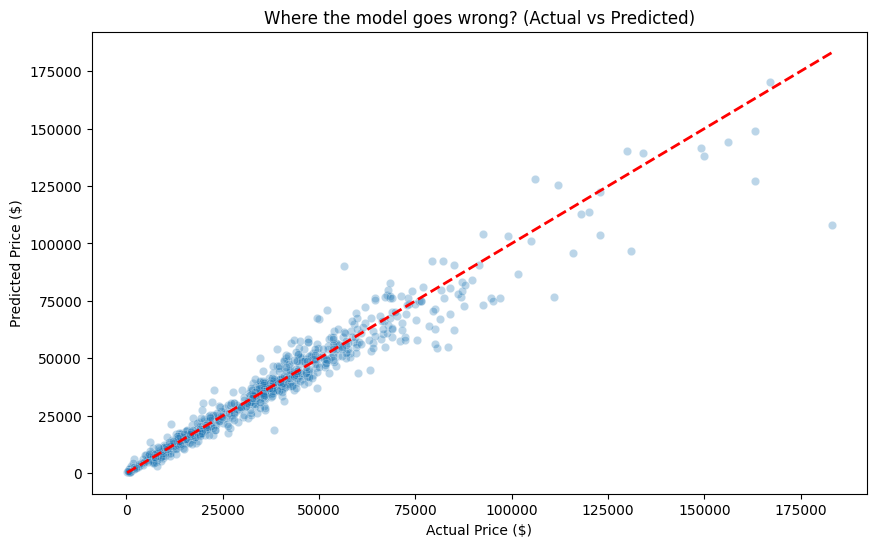

make
Rolls-Royce     0.060701
Tesla           0.083527
Maserati        0.086795
Bentley         0.113192
Land Rover      0.128101
Porsche         0.151512
Ferrari         0.160167
Aston Martin    0.169338
Lamborghini     0.175620
Name: percent_error, dtype: float64


In [11]:
# luxury model
X = df_luxury[features]
y = df_luxury['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_luxury.fit(X_train, y_train)
y_pred = model_luxury.predict(X_test)

print(f"Bład MAE: {mean_absolute_error(y_test, y_pred):.2f}$")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# CALCULATE PERCENTAGE ERROR
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
results['error'] = results['actual'] - results['predicted']
results['abs_error'] = results['error'].abs()
results['percent_error'] = (results['abs_error'] / results['actual']) * 100

print(f"Mean absolute percentage error (MAPE): {results['percent_error'].mean():.2f}%")

# ACTUAL vs PREDICTED CHART
plt.figure(figsize=(10,6))
sns.scatterplot(x='actual', y='predicted', data=results, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title("Where the model goes wrong? (Actual vs Predicted)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.show()

# PERCENTAGE ERROR BY BRAND
results_make = X_test.copy()
results_make['actual'] = y_test
results_make['predicted'] = y_pred
results_make['error'] = results_make['actual'] - results_make['predicted']
results_make['abs_error'] = results_make['error'].abs()
results_make['percent_error'] = results_make['abs_error'] / results_make['actual']
results_make = results_make.groupby('make')['percent_error'].mean()

print(results_make.sort_values())

Bład MAE: 1613.07$
R2 Score: 0.9102
Mean absolute percentage error (MAPE): 16.08%


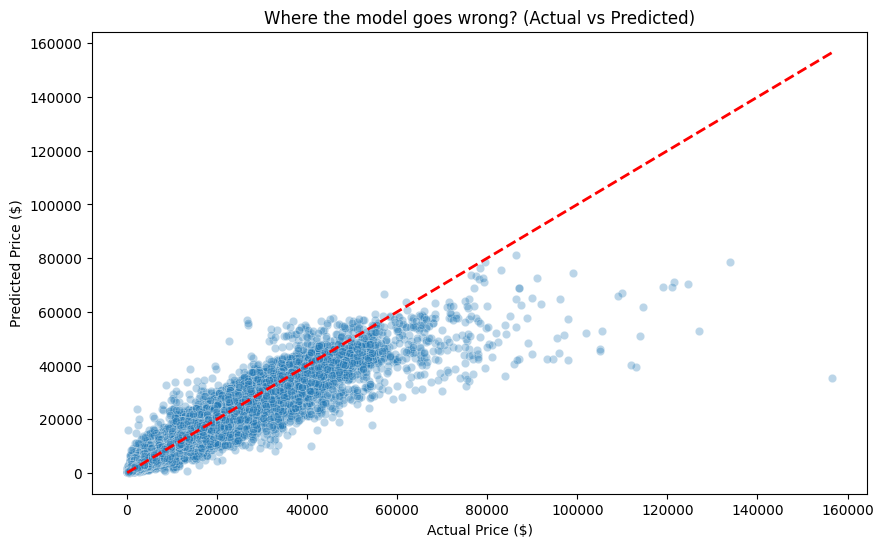

make
Infiniti         0.088839
Lexus            0.111283
Ram              0.120152
Hummer           0.124044
Mini             0.124998
Fiat             0.126316
Kia              0.129987
Nissan           0.133100
Acura            0.139171
Hyundai          0.140583
Toyota           0.141282
Mercedes-Benz    0.142815
Bmw              0.147569
Lincoln          0.150129
Scion            0.156171
Honda            0.160879
Ford             0.164053
Smart            0.168478
Jeep             0.170698
Gmc              0.172805
Mazda            0.173611
Chevrolet        0.174073
Audi             0.174153
Subaru           0.174821
Buick            0.185887
Volkswagen       0.186739
Chrysler         0.187524
Dodge            0.188414
Geo              0.190048
Volvo            0.198240
Mitsubishi       0.217986
Jaguar           0.222346
Cadillac         0.222962
Suzuki           0.284913
Pontiac          0.290943
Saturn           0.304624
Mercury          0.318711
Oldsmobile       0.376344
Saab   

In [12]:
# normal model
X = df_normal[features]
y = df_normal['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_normal.fit(X_train, y_train)
y_pred = model_normal.predict(X_test)

print(f"Bład MAE: {mean_absolute_error(y_test, y_pred):.2f}$")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# CALCULATE PERCENTAGE ERROR
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
results['error'] = results['actual'] - results['predicted']
results['abs_error'] = results['error'].abs()
results['percent_error'] = (results['abs_error'] / results['actual']) * 100

print(f"Mean absolute percentage error (MAPE): {results['percent_error'].mean():.2f}%")

# ACTUAL vs PREDICTED CHART
plt.figure(figsize=(10,6))
sns.scatterplot(x='actual', y='predicted', data=results, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title("Where the model goes wrong? (Actual vs Predicted)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.show()

# PERCENTAGE ERROR BY BRAND
results_make = X_test.copy()
results_make['actual'] = y_test
results_make['predicted'] = y_pred
results_make['error'] = results_make['actual'] - results_make['predicted']
results_make['abs_error'] = results_make['error'].abs()
results_make['percent_error'] = results_make['abs_error'] / results_make['actual']
results_make = results_make.groupby('make')['percent_error'].mean()

print(results_make.sort_values())

In [ ]:
# UPLOADING MODEL TO AWS
model_filename = 'car_valuation_model.joblib'
BUCKET = "konrad-ds-project-data"
joblib.dump(pipeline, model_filename)

s3 = boto3.client('s3')
s3.upload_file(model_filename, BUCKET, f'models/{model_filename}')
print("The model has been upload to S3.")